# **Lasso 모델 분석 및 What-if 시나리오 예측 (검단신도시)**

### 1. 라이브러리 임포트

In [20]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

### 2. 데이터 불러오기

In [21]:
# 훈련용 데이터 (기존 신도시) 및 테스트용 데이터 (검단) 경로 설정
train_folder = r"C:\Users\SJ\Desktop\26-1\데이터마이닝\파주시아파트"
test_folder = r"C:\Users\SJ\Desktop\26-1\데이터마이닝\검단아파트"

# 기존 신도시 데이터에서 운정, 광교, 판교만 훈련 데이터로 사용
df_all = pd.read_csv(train_folder + r"\new_city.csv", encoding='utf-8-sig')
df_train = df_all[df_all['도시명'].isin(['운정', '광교', '판교'])].copy()

# 검단 데이터 불러오기
df_test = pd.read_csv(test_folder + r"\geomdan_merged.csv", encoding='utf-8-sig')

### 3. 데이터 전처리

In [22]:
# 거래금액 쉼표 제거 후 정수 변환
df_train['거래금액(만원)'] = df_train['거래금액(만원)'].str.replace(',', '').astype(int)
df_test['거래금액(만원)'] = df_test['거래금액(만원)'].str.replace(',', '').astype(int)

# 전용면적당 가격(m2당가격) 파생변수 생성
df_train['m2당가격'] = df_train['거래금액(만원)'] / df_train['전용면적(㎡)']
df_test['m2당가격'] = df_test['거래금액(만원)'] / df_test['전용면적(㎡)']

### 4. 훈련/테스트 데이터 분리

In [23]:
# 발표후경과년수 3년 미만 데이터 제거 (신도시 초기 불안정 거래 제외)
df_train = df_train[df_train['발표후경과년수'] >= 3]
df_test = df_test[df_test['발표후경과년수'] >= 3]

# 검단 데이터 중 2022년 이하는 훈련에 포함, 2023년 이후는 테스트로 사용
df_geomdan_train = df_test[df_test['계약연도'] <= 2022].copy()
df_test = df_test[df_test['계약연도'] >= 2023].copy()
df_train = pd.concat([df_train, df_geomdan_train], ignore_index=True)

### 5. 이상치 제거

In [24]:
# 전용면적 33제곱미터 미만 제거
df_train = df_train[df_train['전용면적(㎡)'] >= 33]

# 발표후경과년수 3년미만 필터링
before = len(df_train)
df_train = df_train[df_train['발표후경과년수'] >= 3]
print(f"발표후경과년수 3 미만 제거: {before - len(df_train)}개 → 남은 데이터: {len(df_train)}개")

# m2당가격 z-score 기준 이상치 제거 (|z| > 2인 데이터 제거)
mean = df_train['m2당가격'].mean()
std = df_train['m2당가격'].std()
z_scores = (df_train['m2당가격'] - mean) / std
df_train = df_train[z_scores.abs() <= 2]

print(f"훈련 데이터: {len(df_train)}건")
print(f"테스트 데이터: {len(df_test)}건")

발표후경과년수 3 미만 제거: 0개 → 남은 데이터: 59664개
훈련 데이터: 55950건
테스트 데이터: 8152건


### 6. 독립변수 설정 및 표준화

In [25]:
# 독립변수 목록
features = ['건축년도', '층',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리',
            '단지별_세대수', '도시별_세대수']

# 결측치 제거
df_train = df_train.dropna(subset=features + ['m2당가격'])

# 훈련 데이터 독립변수와 타겟 분리
train_input = df_train[features]
train_target = df_train['m2당가격']

# 표준화
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)

### 7. 최적 alpha 탐색 및 모델 학습

In [26]:
# alpha 값별로 Lasso 모델 학습 및 점수 저장
train_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
models = []

for alpha in alpha_list:
    lasso_a = Lasso(alpha=alpha, max_iter=100000)
    lasso_a.fit(train_scaled, train_target)
    train_score.append(lasso_a.score(train_scaled, train_target))
    models.append(lasso_a)

# 훈련 점수가 가장 높은 alpha 선택
best_idx = train_score.index(max(train_score))
best_alpha = alpha_list[best_idx]
lasso_best = models[best_idx]

### 8. 테스트 데이터 평가

In [27]:
# 테스트 데이터 결측치 제거 및 표준화
df_test = df_test.dropna(subset=features + ['m2당가격'])
test_input = df_test[features]
test_target = df_test['m2당가격']
test_scaled = ss.transform(test_input)

# 성능 출력
print(f"최적 alpha: {best_alpha}")
print(f"훈련 R²: {lasso_best.score(train_scaled, train_target):.4f}")
print(f"테스트 R²: {lasso_best.score(test_scaled, test_target):.4f}")

최적 alpha: 0.001
훈련 R²: 0.8221
테스트 R²: 0.7295


### 9. What-if 분석: 파밀리에 엘리프 기본 특성값 정의

In [28]:
# 파밀리에 엘리프 기본 특성값
엘리프_기본 = {
    '건축년도': 2027,
    '층': 10,
    '지하철호선개수': 2,
    '기차역까지의거리': 15.6213,
    '가장 가까운 지하철역까지의 거리': 1.206,
    '가장 가까운 IC와의 거리': 4.867,
    '발표후경과년수': 21,
    'CPI': 122.6,
    '계약연도': 2027,
    '서울도심거리': 26.5,
    '단지별_세대수': 669,
    '도시별_세대수': 60833
}

### 10. What-if 시나리오 정의

In [29]:
# 층수별 목록
층수_목록 = {'저층 (3층)': 3, '중층 (10층)': 10, '고층 (20층)': 20}

# 시나리오별 특성값 (기본값에서 변경되는 항목만 덮어쓰기)
시나리오_목록 = {
    '현재': 엘리프_기본.copy(),
    '발표 후 25년': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 136.4},
    '지하철 추가': {**엘리프_기본, '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
    '복합 시나리오': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 136.4,
                  '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
}

### 11. 층수별 x 시나리오별 예측 (84제곱미터)

In [30]:
면적_84 = 84.0

print(f"{'='*60}")
print(f"파밀리에 엘리프 층수별 × 시나리오별 예측 (84㎡)")
print(f"{'='*60}")

# 층수별로 각 시나리오의 예측 금액 계산
층수_결과 = {}
for 층이름, 층값 in 층수_목록.items():
    층수_결과[층이름] = []
    for 시나리오명, 값 in 시나리오_목록.items():
        입력값 = dict(값)
        입력값['층'] = 층값
        입력 = pd.DataFrame([입력값])[features]
        입력_scaled = ss.transform(입력)
        예측_m2 = lasso_best.predict(입력_scaled)[0]
        예측_금액 = int(예측_m2 * 면적_84)
        층수_결과[층이름].append(예측_금액)
        print(f"{층이름} | {시나리오명}: {예측_금액:,}만원 ({예측_금액/10000:.1f}억)")

파밀리에 엘리프 층수별 × 시나리오별 예측 (84㎡)
저층 (3층) | 현재: 55,408만원 (5.5억)
저층 (3층) | 발표 후 25년: 61,057만원 (6.1억)
저층 (3층) | 지하철 추가: 61,642만원 (6.2억)
저층 (3층) | 복합 시나리오: 67,291만원 (6.7억)
중층 (10층) | 현재: 56,317만원 (5.6억)
중층 (10층) | 발표 후 25년: 61,966만원 (6.2억)
중층 (10층) | 지하철 추가: 62,550만원 (6.3억)
중층 (10층) | 복합 시나리오: 68,199만원 (6.8억)
고층 (20층) | 현재: 57,615만원 (5.8억)
고층 (20층) | 발표 후 25년: 63,264만원 (6.3억)
고층 (20층) | 지하철 추가: 63,848만원 (6.4억)
고층 (20층) | 복합 시나리오: 69,497만원 (6.9억)


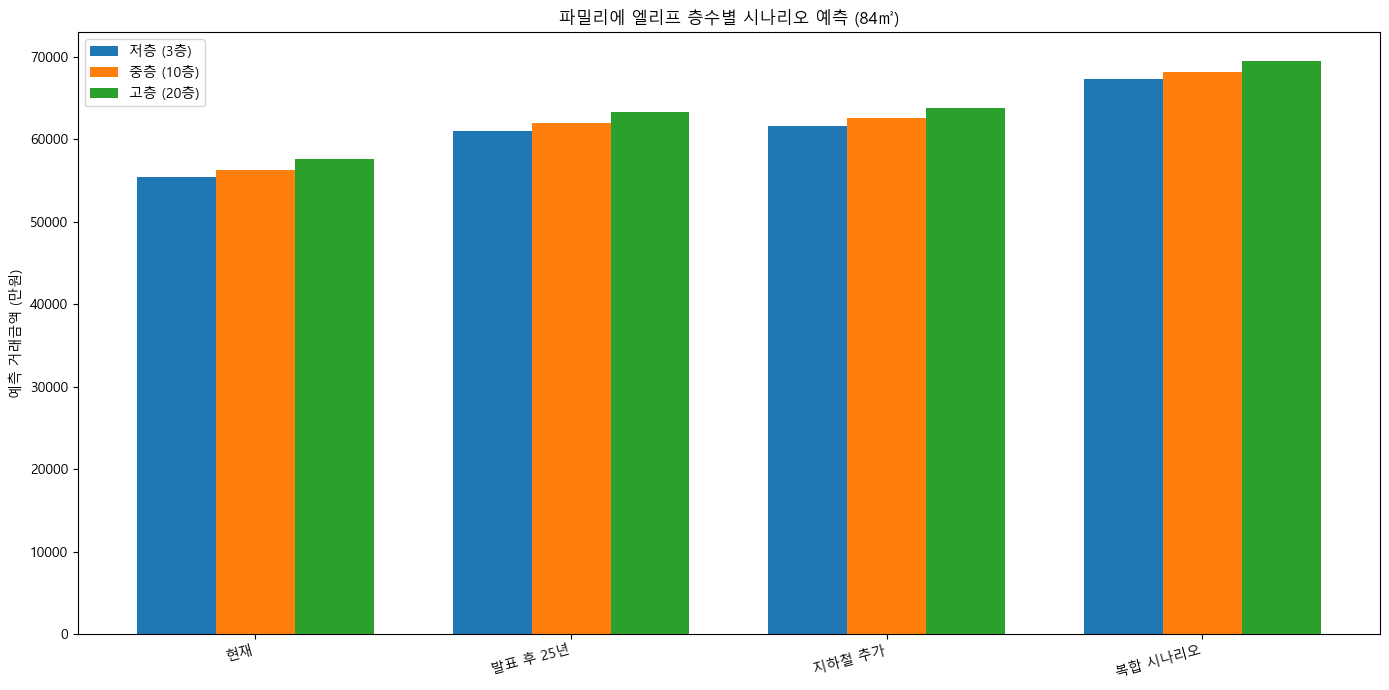

In [31]:
# 층수별 시나리오 예측 막대 그래프
x = np.arange(len(시나리오_목록))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
for i, (층이름, 값들) in enumerate(층수_결과.items()):
    ax.bar(x + i * width, 값들, width, label=층이름)
ax.set_xticks(x + width)
ax.set_xticklabels(시나리오_목록.keys(), rotation=15, ha='right')
ax.set_ylabel('예측 거래금액 (만원)')
ax.set_title('파밀리에 엘리프 층수별 시나리오 예측 (84㎡)')
ax.legend()
plt.tight_layout()
plt.show()

### 12. 평수별 x 시나리오별 예측 (중층 10층)

In [32]:
평수_목록 = {'64㎡': 64.0, '84㎡': 84.0, '98㎡': 98.0, '110㎡': 110.0}

print(f"{'='*60}")
print(f"파밀리에 엘리프 평수별 × 시나리오별 예측 (중층 10층)")
print(f"{'='*60}")

# 평수별로 각 시나리오의 예측 금액 계산
평수_결과 = {}
for 평수이름, 면적값 in 평수_목록.items():
    평수_결과[평수이름] = []
    for 시나리오명, 값 in 시나리오_목록.items():
        입력 = pd.DataFrame([값])[features]
        입력_scaled = ss.transform(입력)
        예측_m2 = lasso_best.predict(입력_scaled)[0]
        예측_금액 = int(예측_m2 * 면적값)
        평수_결과[평수이름].append(예측_금액)
        print(f"{평수이름} | {시나리오명}: {예측_금액:,}만원 ({예측_금액/10000:.1f}억)")

파밀리에 엘리프 평수별 × 시나리오별 예측 (중층 10층)
64㎡ | 현재: 42,908만원 (4.3억)
64㎡ | 발표 후 25년: 47,212만원 (4.7억)
64㎡ | 지하철 추가: 47,657만원 (4.8억)
64㎡ | 복합 시나리오: 51,961만원 (5.2억)
84㎡ | 현재: 56,317만원 (5.6억)
84㎡ | 발표 후 25년: 61,966만원 (6.2억)
84㎡ | 지하철 추가: 62,550만원 (6.3억)
84㎡ | 복합 시나리오: 68,199만원 (6.8억)
98㎡ | 현재: 65,703만원 (6.6억)
98㎡ | 발표 후 25년: 72,294만원 (7.2억)
98㎡ | 지하철 추가: 72,975만원 (7.3억)
98㎡ | 복합 시나리오: 79,566만원 (8.0억)
110㎡ | 현재: 73,749만원 (7.4억)
110㎡ | 발표 후 25년: 81,146만원 (8.1억)
110㎡ | 지하철 추가: 81,911만원 (8.2억)
110㎡ | 복합 시나리오: 89,309만원 (8.9억)


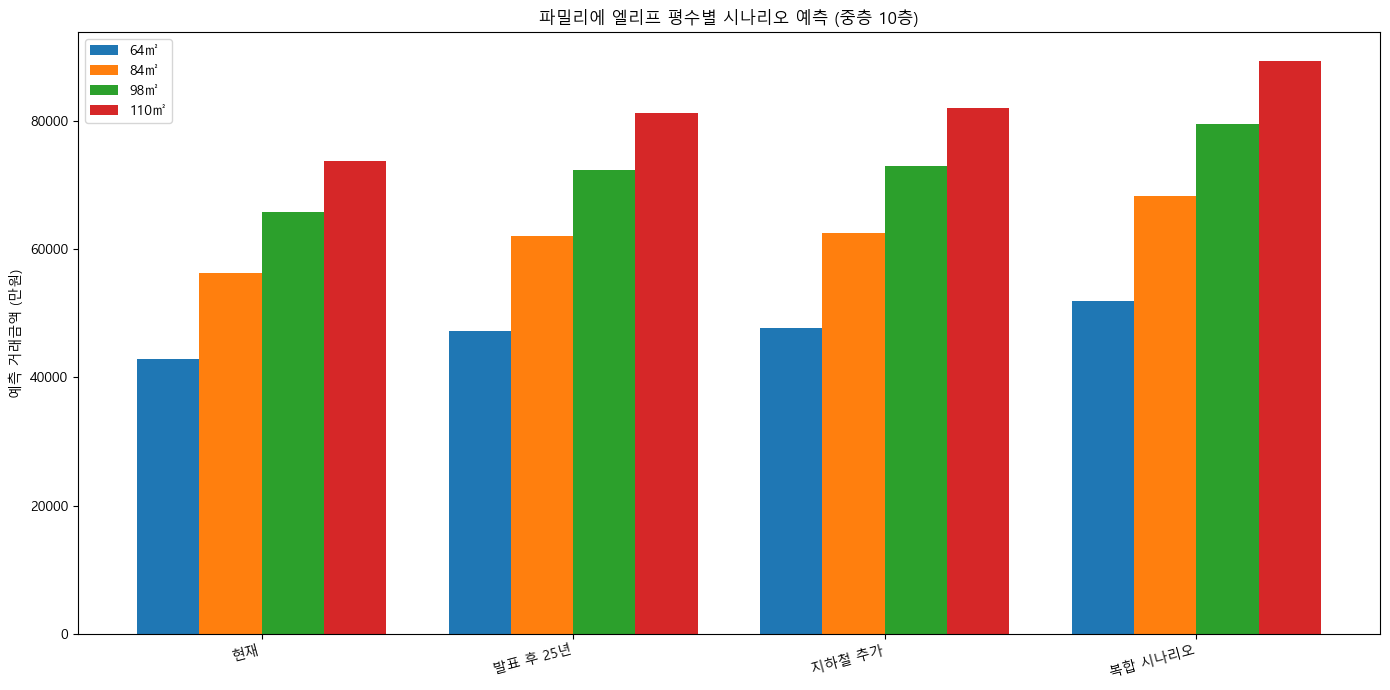

In [33]:
# 평수별 시나리오 예측 막대 그래프
x = np.arange(len(시나리오_목록))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))
for i, (평수이름, 값들) in enumerate(평수_결과.items()):
    ax.bar(x + i * width, 값들, width, label=평수이름)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(시나리오_목록.keys(), rotation=15, ha='right')
ax.set_ylabel('예측 거래금액 (만원)')
ax.set_title('파밀리에 엘리프 평수별 시나리오 예측 (중층 10층)')
ax.legend()
plt.tight_layout()
plt.show()